# Notebook 10: Training a Neural Network



## 1. The Training Pipeline

To train a model, we must follow these 12 steps in order:
1.  **Load Data:** Get raw data.
2.  **Prepare Features:** Clean and encode.
3.  **Split Data:** Create Train and Validation sets.
4.  **Create Tensors:** Convert NumPy/Pandas $\rightarrow$ PyTorch.
5.  **Create Model:** Define the `nn.Module`.
6.  **Select Loss Function:** (e.g., `BCEWithLogitsLoss`).
7.  **Select Optimizer:** (e.g., `Adam`).
8.  **Forward Pass:** Get predictions.
9.  **Calculate Loss:** Compare predictions to targets.
10. **Backpropagation:** Calculate gradients using `.backward()`.
11. **Update Weights:** Adjust weights using `optimizer.step()`.
12. **Repeat:** Do this for multiple **Epochs**.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1-4. Data Loading and Preparation
X, y = make_classification(n_samples=1000, n_features=20, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).reshape(-1, 1)
X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.float32).reshape(-1, 1)

# 5. Create Model
class SimpleNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(20, 16),
            nn.ReLU(),
            nn.Linear(16, 1),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.net(x)

model = SimpleNet()

# 6-7. Loss and Optimizer
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# Training Loop
epochs = 50
train_losses = []
val_losses = []

for epoch in range(epochs):
    # --- Training Phase ---
    model.train()
    optimizer.zero_grad()
    
    # 8-11. Forward, Loss, Backward, Update
    preds = model(X_train_t)
    loss = criterion(preds, y_train_t)
    loss.backward()
    optimizer.step()
    
    # --- Validation Phase ---
    model.eval()
    with torch.no_grad():
        val_preds = model(X_val_t)
        v_loss = criterion(val_preds, y_val_t)
    
    train_losses.append(loss.item())
    val_losses.append(v_loss.item())
    
    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {loss.item():.4f} | Val Loss: {v_loss.item():.4f}")

Epoch 10/50 | Train Loss: 0.5481 | Val Loss: 0.5694
Epoch 20/50 | Train Loss: 0.3858 | Val Loss: 0.4447
Epoch 30/50 | Train Loss: 0.2926 | Val Loss: 0.3860
Epoch 40/50 | Train Loss: 0.2597 | Val Loss: 0.3875
Epoch 50/50 | Train Loss: 0.2390 | Val Loss: 0.3917


## 2. Understanding Training Terminology

- **Epoch:** One full pass of the entire training dataset through the network.
- **Batch:** A small subset of data used for one weight update (e.g., 32 samples).
- **Iteration:** One single weight update (1 iteration = 1 batch processed).
- **Learning Rate:** How big of a step we take during weight updates.
- **Training Loss:** Error on the data the model is seeing.
- **Validation Loss:** Error on unseen data; used to detect overfitting.

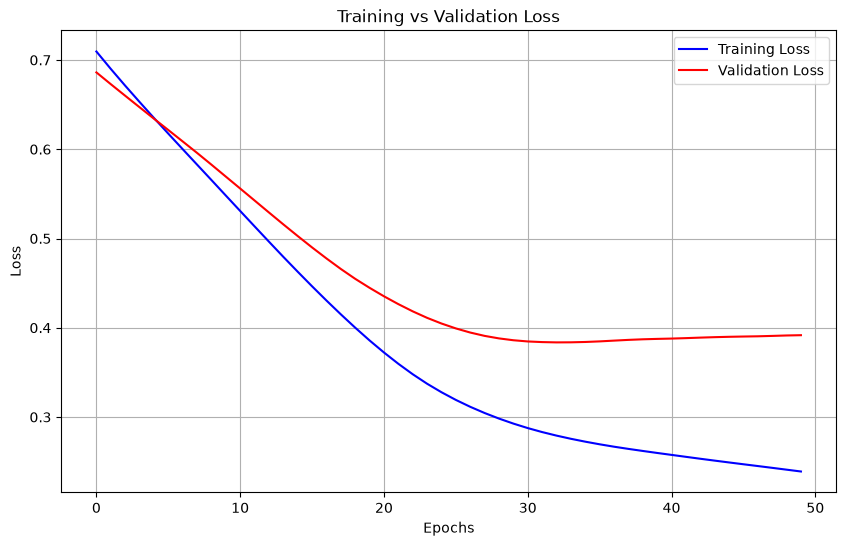

In [2]:
# Plotting the loss curves
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label="Training Loss", color="blue")
plt.plot(val_losses, label="Validation Loss", color="red")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

## 3. Interpreting the Curves

- **Underfitting:** Both training and validation loss remain high.
- **Overfitting:** Training loss continues to drop, but validation loss starts to **increase**. This means the model is memorizing the training data and losing the ability to generalize.
- **Good Fit:** Both curves decrease and flatten out close to each other.